# Global Warming Acceleration & Committed Warming: Multi-Source Hemispheric Asymmetry and 3-Box EBM Simulation with Ocean Solubility Feedback

This notebook explores global surface temperature anomaly records from four widely used datasets:

Original GitHub repository: https://github.com/ByeonggeonGo/global_temperature_trend

- **NASA GISTEMP v4** global land-ocean temperature index
- **NOAA GlobalTemp v6.1** global land-ocean temperature anomalies
- **HadCRUT5** global monthly analysis with uncertainty intervals
- **Berkeley Earth High-Resolution** global monthly land-ocean series

The analysis is designed for a public GitHub/Kaggle workflow. It emphasizes reproducibility, dataset comparability, and clear communication of uncertainty.

## Main questions

1. How similar are the major global temperature datasets after rebasing them to a common reference period?
2. What is the long-term warming trend, and how does it change after 1970?
3. How much short-term variability sits on top of the warming signal?
4. Are recent years/months exceptional relative to the historical distribution?
5. Can we extend the analysis spatially with gridded data and GeoPandas?

## Important caveat

Temperature anomaly datasets use different native baselines. To compare them fairly, this notebook creates a common `1991-2020` anomaly scale. The original values are preserved, but most comparisons use the rebased values.

## 0. Environment and optional dependencies

The global time-series EDA uses `pandas`, `numpy`, `matplotlib`, and `scipy`. The regional map section additionally needs `netCDF4` and `geopandas`.

If the geospatial packages are missing, uncomment and run the install cell below. Kaggle usually has many packages preinstalled, but local Windows environments often need the explicit install.

In [1]:
import sys
import subprocess

try:
    import netCDF4
    import geopandas
    import pyogrio
    import seaborn
except ImportError:
    print("Dependencies missing. Installing netCDF4, geopandas, shapely, pyogrio, seaborn...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "netCDF4", "geopandas", "shapely", "pyogrio", "seaborn"])


In [2]:
from pathlib import Path
import json
import math
import re
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.stats import linregress, zscore
except Exception:
    linregress = None
    zscore = None

warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path.cwd()
KAGGL_INPUT_DIR = Path("/kaggle/input/global-temperature-trend-source-samples")
DATA_DIR = KAGGL_INPUT_DIR if KAGGL_INPUT_DIR.exists() else ROOT / "temperature_dataset_samples"
OUT_DIR = ROOT / "analysis_outputs"
OUT_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
})

DATA_FILES = {
    "nasa": DATA_DIR / "nasa_gistemp_global_loti.csv",
    "noaa": DATA_DIR / "noaa_globaltemp_v6_1_land_ocean_global.asc",
    "hadcrut5": DATA_DIR / "hadcrut5_5_1_global_monthly.csv",
    "berkeley": DATA_DIR / "berkeley_earth_hr_global_monthly.txt",
}

missing = [str(path) for path in DATA_FILES.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing input files. Run check_temperature_datasets.py first: " + ", ".join(missing))

## 1. Load and standardize the four global time series

Each loader returns a monthly table with:

- `dataset`
- `date`
- `year`
- `month`
- `anomaly_c`
- optional uncertainty columns when available

The files differ in format: NASA uses a wide annual CSV, NOAA uses whitespace-delimited ASCII, HadCRUT5 uses a tidy CSV, and Berkeley Earth uses a text file with metadata comments.

In [3]:
def load_nasa_gistemp(path: Path) -> pd.DataFrame:
    lines = path.read_text(encoding="utf-8", errors="replace").splitlines()
    header_at = next(i for i, line in enumerate(lines) if line.startswith("Year,"))
    df = pd.read_csv(path, skiprows=header_at)
    month_cols = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    long = df.melt(id_vars="Year", value_vars=month_cols, var_name="month_name", value_name="anomaly_c")
    month_map = {name: i for i, name in enumerate(month_cols, start=1)}
    long["month"] = long["month_name"].map(month_map)
    long["anomaly_c"] = pd.to_numeric(long["anomaly_c"].replace("***", np.nan), errors="coerce")
    long["date"] = pd.to_datetime(dict(year=long["Year"].astype(int), month=long["month"], day=1))
    long["dataset"] = "NASA GISTEMP"
    return long[["dataset", "date", "anomaly_c"]].dropna()


def load_noaa_globaltemp(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep=r"\s+", header=None, comment="#")
    df = df.iloc[:, :3]
    df.columns = ["year", "month", "anomaly_c"]
    df["date"] = pd.to_datetime(dict(year=df["year"].astype(int), month=df["month"].astype(int), day=1))
    df["dataset"] = "NOAA GlobalTemp"
    return df[["dataset", "date", "anomaly_c"]].dropna()


def load_hadcrut5(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["date"] = pd.to_datetime(df["Time"])
    df["anomaly_c"] = pd.to_numeric(df["Anomaly (deg C)"], errors="coerce")
    df["lower_95"] = pd.to_numeric(df["Lower confidence limit (2.5%)"], errors="coerce")
    df["upper_95"] = pd.to_numeric(df["Upper confidence limit (97.5%)"], errors="coerce")
    df["dataset"] = "HadCRUT5"
    return df[["dataset", "date", "anomaly_c", "lower_95", "upper_95"]].dropna(subset=["anomaly_c"])


def load_berkeley(path: Path) -> pd.DataFrame:
    rows = []
    for line in path.read_text(encoding="utf-8", errors="replace").splitlines():
        parts = line.split()
        if len(parts) >= 4 and parts[0].isdigit() and parts[1].isdigit():
            rows.append((int(parts[0]), int(parts[1]), float(parts[2]), float(parts[3])))
    df = pd.DataFrame(rows, columns=["year", "month", "anomaly_c", "uncertainty_95"])
    df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=1))
    df["dataset"] = "Berkeley Earth HR"
    return df[["dataset", "date", "anomaly_c", "uncertainty_95"]]


series = pd.concat([
    load_nasa_gistemp(DATA_FILES["nasa"]),
    load_noaa_globaltemp(DATA_FILES["noaa"]),
    load_hadcrut5(DATA_FILES["hadcrut5"]),
    load_berkeley(DATA_FILES["berkeley"]),
], ignore_index=True, sort=False)

series["year"] = series["date"].dt.year
series["month"] = series["date"].dt.month
series["decimal_year"] = series["year"] + (series["month"] - 0.5) / 12

baseline_mask = series["year"].between(1991, 2020)
baseline = series[baseline_mask].groupby("dataset")["anomaly_c"].mean()
series["anom_1991_2020"] = series["anomaly_c"] - series["dataset"].map(baseline)

coverage = series.groupby("dataset").agg(
    start=("date", "min"),
    end=("date", "max"),
    months=("date", "count"),
    native_mean_1991_2020=("anomaly_c", lambda s: s[series.loc[s.index, "year"].between(1991, 2020)].mean()),
    missing_months=("anomaly_c", lambda s: s.isna().sum()),
).sort_index()
coverage

,start,end,months,native_mean_1991_2020,missing_months
dataset,,,,,
Berkeley Earth HR,1850-01-01,2026-05-01,2117,6.321944e-01,0
HadCRUT5,1850-01-01,2026-03-01,2115,5.379955e-01,0
NASA GISTEMP,1880-01-01,2026-05-01,1757,6.121944e-01,0
NOAA GlobalTemp,1850-01-01,2026-05-01,2117,3.361111e-07,0


### EDA note: baseline compatibility

The table above is a quick audit. The native `1991-2020` mean differs because each dataset has its own original anomaly baseline. After subtracting that mean, all datasets are on a comparable `1991-2020 = 0` scale.

## 2. Annual aggregation, completeness checks, and core trend metrics

Annual means are computed from monthly values. Years with fewer than 10 available months are excluded to avoid partial-year distortions. This matters for the current year, which is usually incomplete.

In [4]:
annual = (
    series.groupby(["dataset", "year"], as_index=False)
    .agg(
        anom_1991_2020=("anom_1991_2020", "mean"),
        native_anomaly_c=("anomaly_c", "mean"),
        months=("month", "count"),
    )
)
annual = annual[annual["months"] >= 10].copy()


def trend_per_decade(df: pd.DataFrame, start_year: int | None = None, end_year: int | None = None) -> dict:
    d = df.dropna(subset=["year", "anom_1991_2020"]).copy()
    if start_year is not None:
        d = d[d["year"] >= start_year]
    if end_year is not None:
        d = d[d["year"] <= end_year]
    x = d["year"].to_numpy(dtype=float)
    y = d["anom_1991_2020"].to_numpy(dtype=float)
    if len(d) < 3:
        return {"n_years": len(d), "trend_c_per_decade": np.nan, "p_value": np.nan, "r2": np.nan, "intercept": np.nan}
    if linregress is not None:
        fit = linregress(x, y)
        return {
            "n_years": len(d),
            "trend_c_per_decade": fit.slope * 10,
            "p_value": fit.pvalue,
            "r2": fit.rvalue ** 2,
            "intercept": fit.intercept,
        }
    slope, intercept = np.polyfit(x, y, 1)
    yhat = slope * x + intercept
    r2 = 1 - np.sum((y - yhat) ** 2) / np.sum((y - y.mean()) ** 2)
    return {"n_years": len(d), "trend_c_per_decade": slope * 10, "p_value": np.nan, "r2": r2, "intercept": intercept}

periods = {
    "full record": (None, None),
    "1950-present": (1950, None),
    "1970-present": (1970, None),
    "1990-present": (1990, None),
    "2000-present": (2000, None),
}

trend_rows = []
for dataset, group in annual.groupby("dataset"):
    for label, (start, end) in periods.items():
        trend_rows.append({"dataset": dataset, "period": label, **trend_per_decade(group, start, end)})

trends = pd.DataFrame(trend_rows).sort_values(["period", "dataset"])
trends[["dataset", "period", "n_years", "trend_c_per_decade", "r2", "p_value"]]

,dataset,period,n_years,trend_c_per_decade,r2,p_value
1,Berkeley Earth HR,1950-present,76,0.162794,0.873212,6.431363e-35
6,HadCRUT5,1950-present,76,0.158255,0.864790,6.980227e-34
11,NASA GISTEMP,1950-present,76,0.161002,0.883424,2.861114e-36
16,NOAA GlobalTemp,1950-present,76,0.154258,0.879238,1.057738e-35
2,Berkeley Earth HR,1970-present,56,0.205827,0.909533,7.565027e-30
7,HadCRUT5,1970-present,56,0.204060,0.912953,2.667944e-30
12,NASA GISTEMP,1970-present,56,0.201842,0.908158,1.137697e-29
17,NOAA GlobalTemp,1970-present,56,0.194546,0.908529,1.019533e-29
3,Berkeley Earth HR,1990-present,36,0.227437,0.836385,6.375109e-15
8,HadCRUT5,1990-present,36,0.228772,0.850904,1.302909e-15


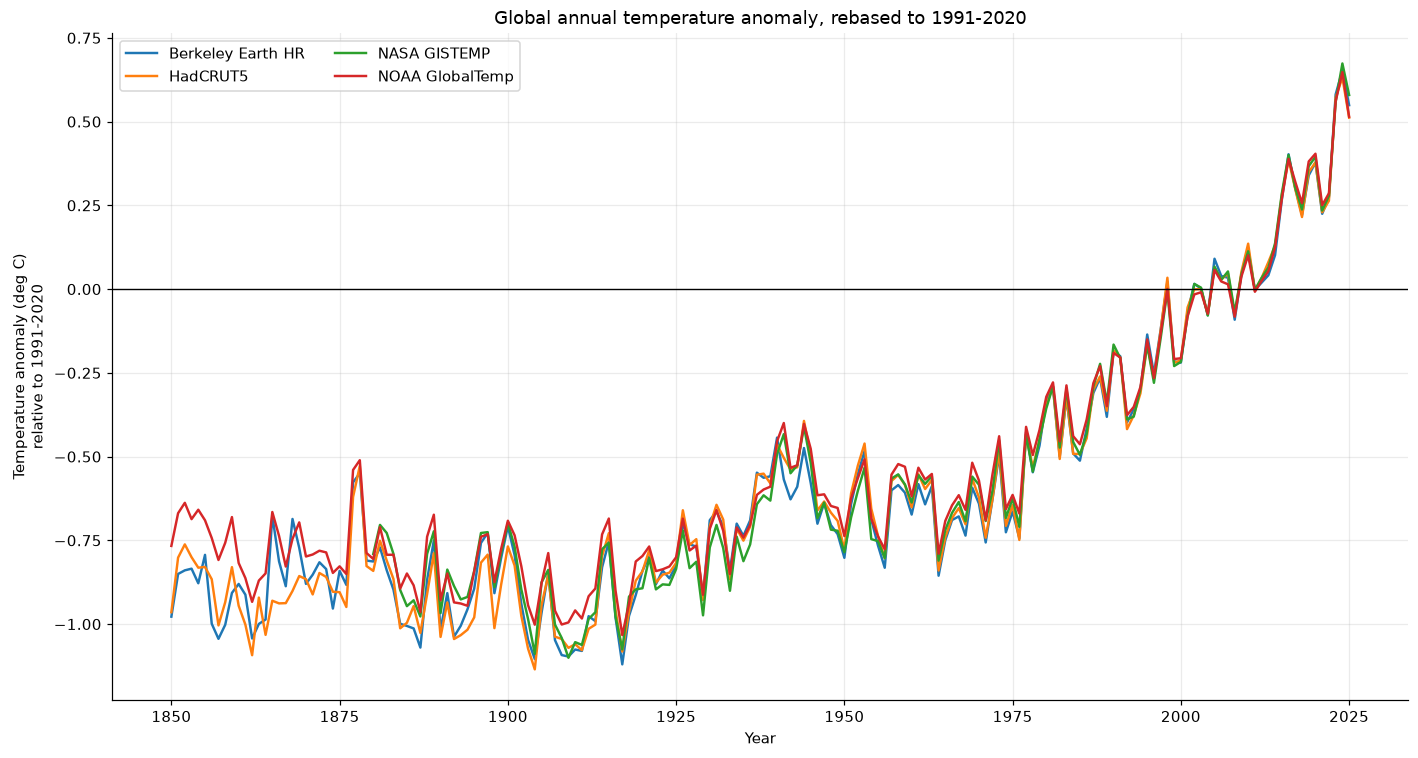

In [5]:
fig, ax = plt.subplots(figsize=(13, 7))
for dataset, group in annual.groupby("dataset"):
    ax.plot(group["year"], group["anom_1991_2020"], linewidth=1.6, label=dataset)

ax.axhline(0, color="black", linewidth=0.9)
ax.set_title("Global annual temperature anomaly, rebased to 1991-2020")
ax.set_ylabel("Temperature anomaly (deg C)\nrelative to 1991-2020")
ax.set_xlabel("Year")
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(OUT_DIR / "global_annual_anomaly_comparison.png", dpi=180)
plt.show()

### Discussion: long-term trend signal

All four datasets tell the same broad story: global temperature has increased substantially since the nineteenth century, and the trend steepens after the mid-twentieth century. The exact slope differs slightly because the products use different interpolation methods, sea-surface temperature inputs, coverage assumptions, and uncertainty treatment.

The most policy-relevant visual feature is not a single record year. It is the sustained shift of the entire annual distribution upward. Once the records are rebased to `1991-2020`, the datasets track each other closely enough that the warming signal is robust to dataset choice.

## 3. Dataset agreement and divergence

A useful EDA check is to measure how far the datasets deviate from their multi-dataset mean. This helps reveal whether conclusions depend on a single source.

In [6]:
wide_annual = annual.pivot(index="year", columns="dataset", values="anom_1991_2020")
wide_annual["multi_dataset_mean"] = wide_annual.mean(axis=1)
for dataset in [c for c in wide_annual.columns if c != "multi_dataset_mean"]:
    wide_annual[f"{dataset} residual"] = wide_annual[dataset] - wide_annual["multi_dataset_mean"]

agreement = []
for dataset in annual["dataset"].unique():
    residual = wide_annual[f"{dataset} residual"].dropna()
    agreement.append({
        "dataset": dataset,
        "mean_abs_residual_c": residual.abs().mean(),
        "max_abs_residual_c": residual.abs().max(),
        "residual_std_c": residual.std(),
        "correlation_with_multi_mean": wide_annual[[dataset, "multi_dataset_mean"]].corr().iloc[0, 1],
    })
agreement = pd.DataFrame(agreement).sort_values("mean_abs_residual_c")
agreement

,dataset,mean_abs_residual_c,max_abs_residual_c,residual_std_c,correlation_with_multi_mean
2,NASA GISTEMP,0.019164,0.089612,0.025377,0.998002
1,HadCRUT5,0.024188,0.172850,0.031891,0.997157
0,Berkeley Earth HR,0.025562,0.129562,0.030948,0.997166
3,NOAA GlobalTemp,0.035624,0.143518,0.034012,0.997216


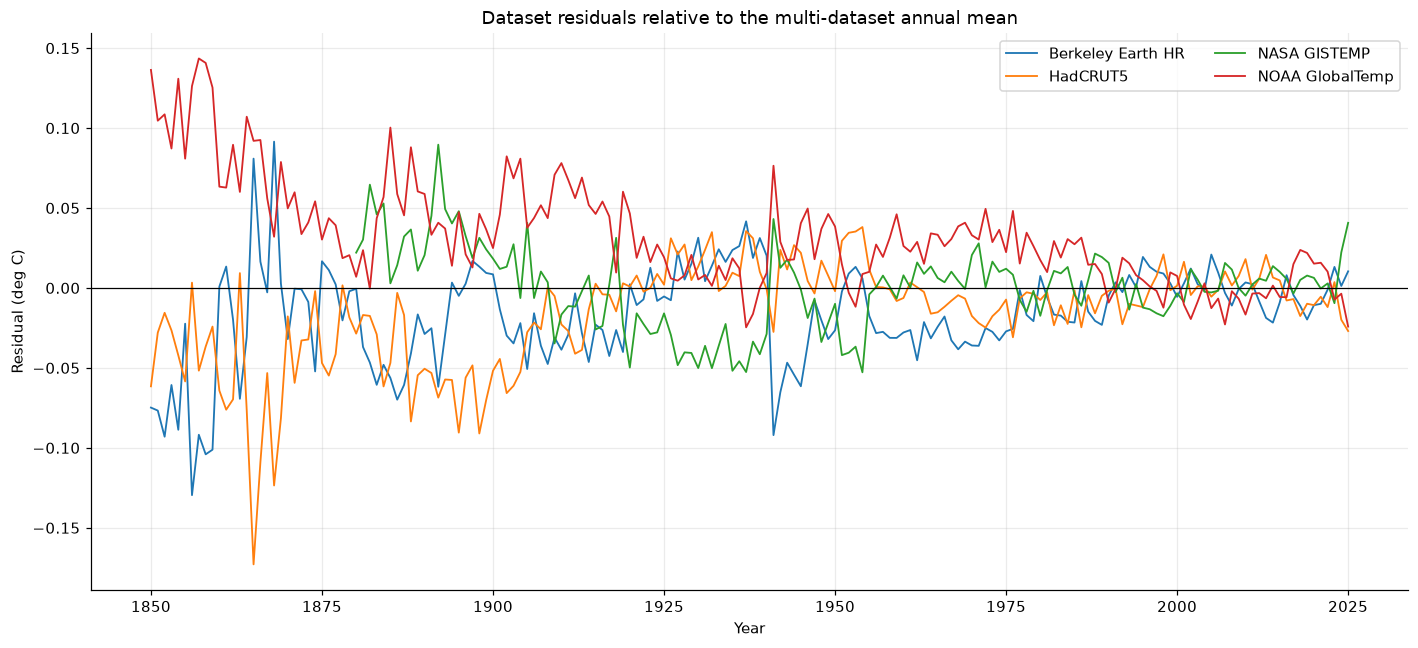

In [7]:
residual_cols = [c for c in wide_annual.columns if c.endswith(" residual")]
fig, ax = plt.subplots(figsize=(13, 6))
for col in residual_cols:
    ax.plot(wide_annual.index, wide_annual[col], linewidth=1.2, label=col.replace(" residual", ""))
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Dataset residuals relative to the multi-dataset annual mean")
ax.set_ylabel("Residual (deg C)")
ax.set_xlabel("Year")
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(OUT_DIR / "dataset_residuals_vs_multisource_mean.png", dpi=180)
plt.show()

### Discussion: agreement across independent products

The residual plot should be read as a method-sensitivity diagnostic. Larger early-period residuals are expected because sparse observations, especially over oceans and polar regions, make historical reconstruction harder. Modern residuals are smaller because observational coverage is denser and satellite-era constraints improve consistency.

For most headline conclusions, the four products are interchangeable. For uncertainty-aware statements, HadCRUT5 and Berkeley Earth are especially useful because they publish uncertainty information in the downloaded time-series products.

## 4. Volatility, short-term variability, and rolling trends

Long-term warming is not smooth. ENSO, volcanic eruptions, aerosol changes, ocean heat uptake, and internal variability create short-term fluctuations. This section separates trend-like movement from short-term volatility.

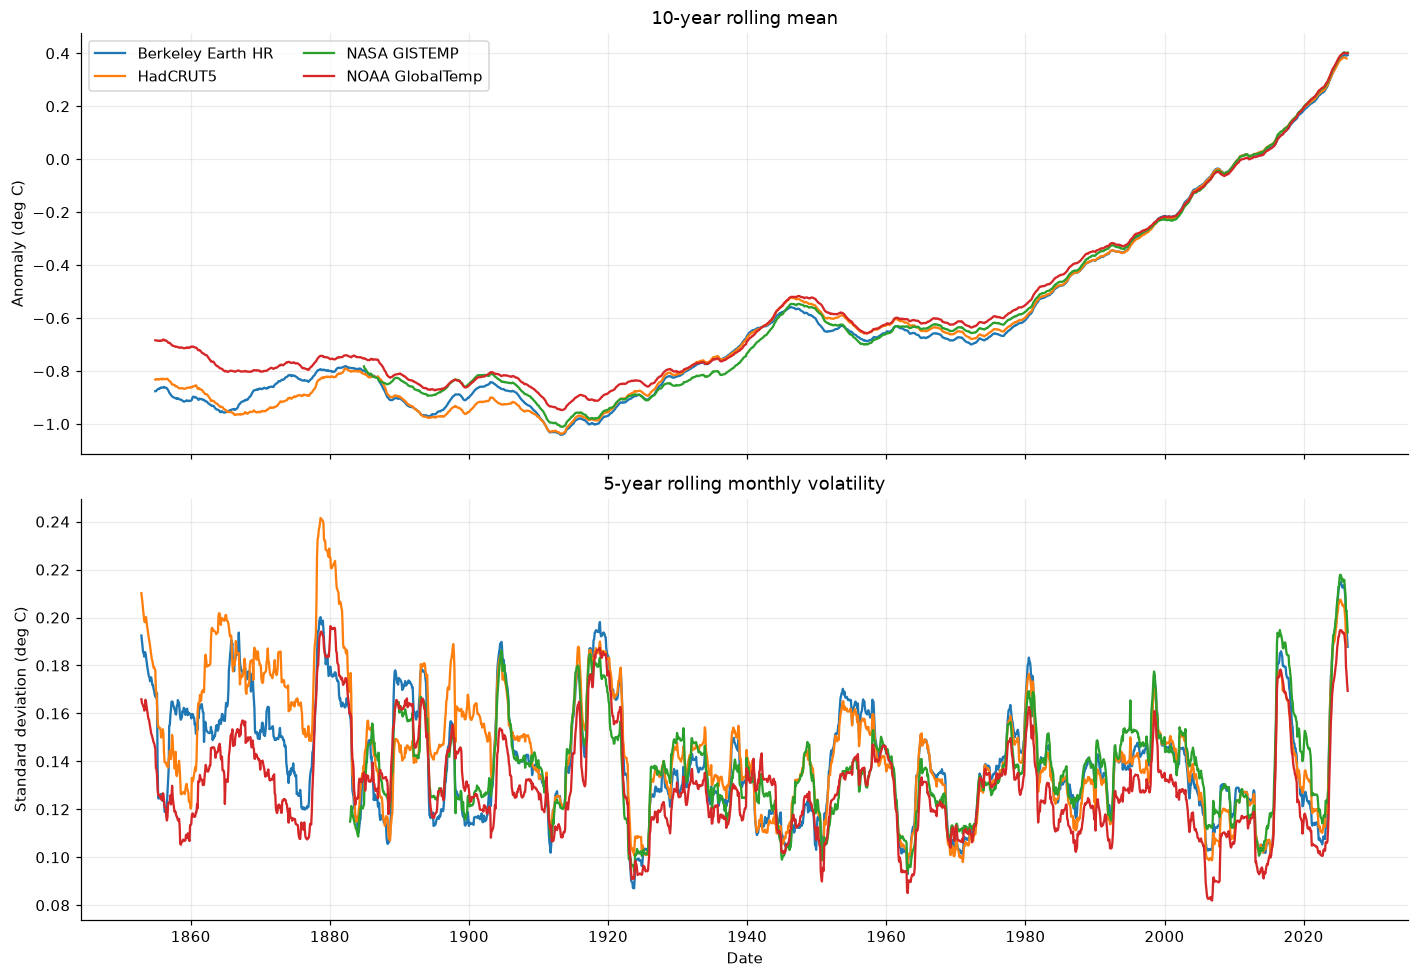

,monthly_std,detrended_std,latest_5yr_std
dataset,,,
Berkeley Earth HR,0.411383,0.161765,0.187773
HadCRUT5,0.414238,0.164181,0.188062
NASA GISTEMP,0.418142,0.158515,0.193847
NOAA GlobalTemp,0.381028,0.149958,0.169433


In [8]:
monthly = series.sort_values(["dataset", "date"]).copy()
monthly["rolling_mean_120m"] = monthly.groupby("dataset")["anom_1991_2020"].transform(lambda s: s.rolling(120, min_periods=60).mean())
monthly["rolling_std_60m"] = monthly.groupby("dataset")["anom_1991_2020"].transform(lambda s: s.rolling(60, min_periods=36).std())
monthly["detrended_residual"] = monthly["anom_1991_2020"] - monthly["rolling_mean_120m"]

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
for dataset, group in monthly.groupby("dataset"):
    axes[0].plot(group["date"], group["rolling_mean_120m"], label=dataset)
    axes[1].plot(group["date"], group["rolling_std_60m"], label=dataset)

axes[0].set_title("10-year rolling mean")
axes[0].set_ylabel("Anomaly (deg C)")
axes[1].set_title("5-year rolling monthly volatility")
axes[1].set_ylabel("Standard deviation (deg C)")
axes[1].set_xlabel("Date")
axes[0].legend(ncol=2)
fig.tight_layout()
fig.savefig(OUT_DIR / "global_trend_and_volatility.png", dpi=180)
plt.show()

vol_summary = monthly.groupby("dataset").agg(
    monthly_std=("anom_1991_2020", "std"),
    detrended_std=("detrended_residual", "std"),
    latest_5yr_std=("rolling_std_60m", "last"),
)
vol_summary

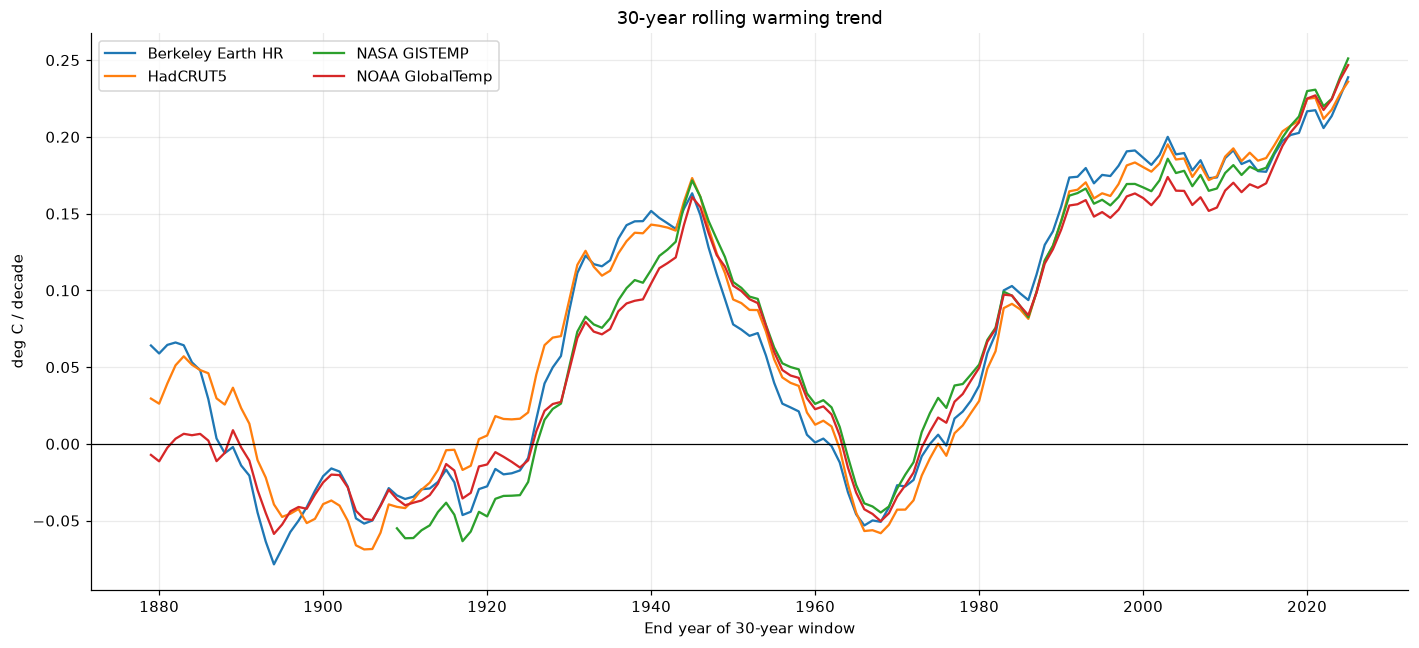

In [9]:
def rolling_trend(group: pd.DataFrame, window_years: int = 30) -> pd.DataFrame:
    d = group[["year", "anom_1991_2020"]].dropna().sort_values("year").copy()
    rows = []
    for end_year in range(int(d["year"].min()) + window_years - 1, int(d["year"].max()) + 1):
        w = d[d["year"].between(end_year - window_years + 1, end_year)]
        if len(w) >= window_years * 0.8:
            stats = trend_per_decade(w)
            rows.append({"dataset": group["dataset"].iloc[0], "end_year": end_year, "rolling_trend_c_per_decade": stats["trend_c_per_decade"]})
    return pd.DataFrame(rows)

rolling_trends = pd.concat([rolling_trend(g, 30) for _, g in annual.groupby("dataset")], ignore_index=True)

fig, ax = plt.subplots(figsize=(13, 6))
for dataset, group in rolling_trends.groupby("dataset"):
    ax.plot(group["end_year"], group["rolling_trend_c_per_decade"], label=dataset)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("30-year rolling warming trend")
ax.set_ylabel("deg C / decade")
ax.set_xlabel("End year of 30-year window")
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(OUT_DIR / "rolling_30_year_trends.png", dpi=180)
plt.show()

### Discussion: variability versus climate trend

Short-term variability is large enough to create unusually warm or cool individual months, but it is much smaller than the multi-decadal shift in the rolling mean. The 30-year rolling trend view is useful because climate normals are typically discussed over multi-decadal windows. A persistent positive rolling trend across datasets is stronger evidence than any single anomalous month.

## 5. Seasonality, month-of-year behavior, and anomaly heatmaps

Global temperature anomalies are usually deseasonalized, but month-specific behavior can still differ because observational coverage, sea ice treatment, and circulation patterns vary through the year.

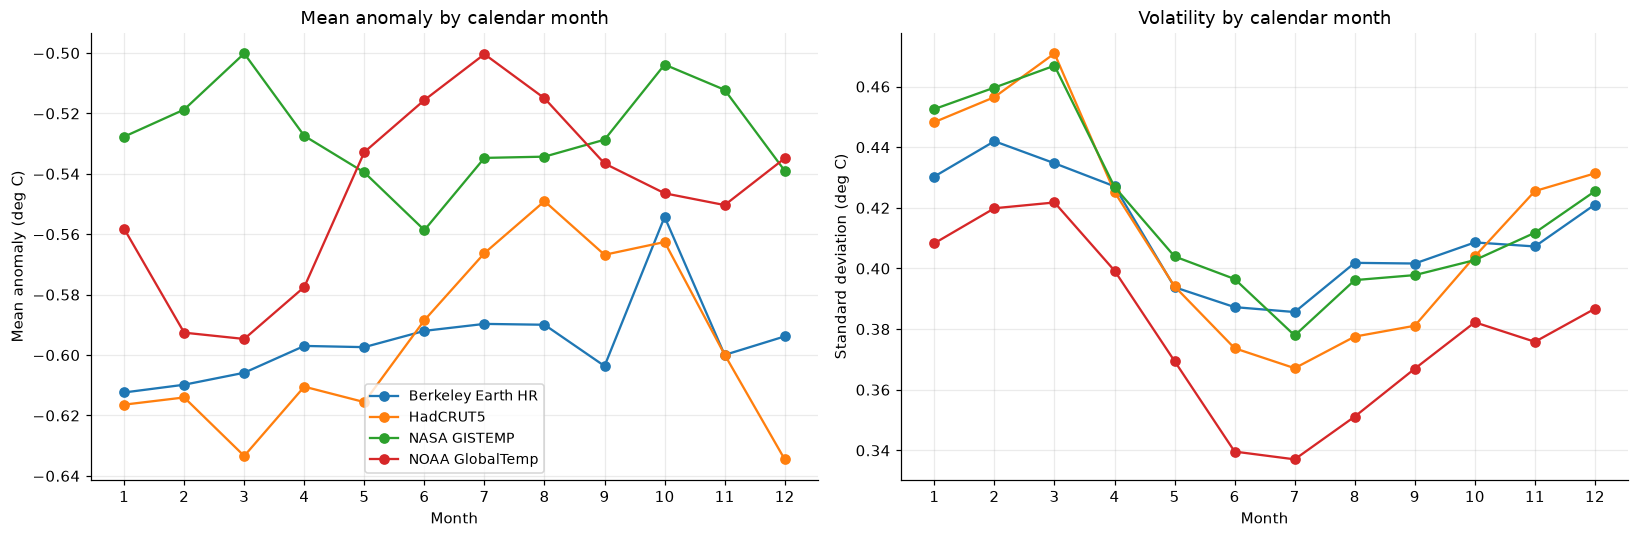

,dataset,month,mean_anomaly,std_anomaly,p05,p95
0,Berkeley Earth HR,1,-0.612387,0.430335,-1.152994,0.244206
1,Berkeley Earth HR,2,-0.609822,0.441978,-1.176594,0.226206
2,Berkeley Earth HR,3,-0.605855,0.434708,-1.115794,0.271406
3,Berkeley Earth HR,4,-0.596980,0.427095,-1.127794,0.276206
4,Berkeley Earth HR,5,-0.597381,0.393821,-1.067194,0.199806
5,Berkeley Earth HR,6,-0.591990,0.387252,-1.069444,0.191056
6,Berkeley Earth HR,7,-0.589683,0.385636,-1.062694,0.220806
7,Berkeley Earth HR,8,-0.589967,0.401859,-1.067694,0.256306
8,Berkeley Earth HR,9,-0.603632,0.401639,-1.073194,0.212806
9,Berkeley Earth HR,10,-0.554274,0.408597,-1.046194,0.297806


In [10]:
monthly_climatology = monthly.groupby(["dataset", "month"]).agg(
    mean_anomaly=("anom_1991_2020", "mean"),
    std_anomaly=("anom_1991_2020", "std"),
    p05=("anom_1991_2020", lambda s: s.quantile(0.05)),
    p95=("anom_1991_2020", lambda s: s.quantile(0.95)),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
for dataset, group in monthly_climatology.groupby("dataset"):
    axes[0].plot(group["month"], group["mean_anomaly"], marker="o", label=dataset)
    axes[1].plot(group["month"], group["std_anomaly"], marker="o", label=dataset)
axes[0].set_title("Mean anomaly by calendar month")
axes[0].set_ylabel("Mean anomaly (deg C)")
axes[1].set_title("Volatility by calendar month")
axes[1].set_ylabel("Standard deviation (deg C)")
for ax in axes:
    ax.set_xlabel("Month")
    ax.set_xticks(range(1, 13))
axes[0].legend(fontsize=9)
fig.tight_layout()
fig.savefig(OUT_DIR / "month_of_year_eda.png", dpi=180)
plt.show()

monthly_climatology.head(12)

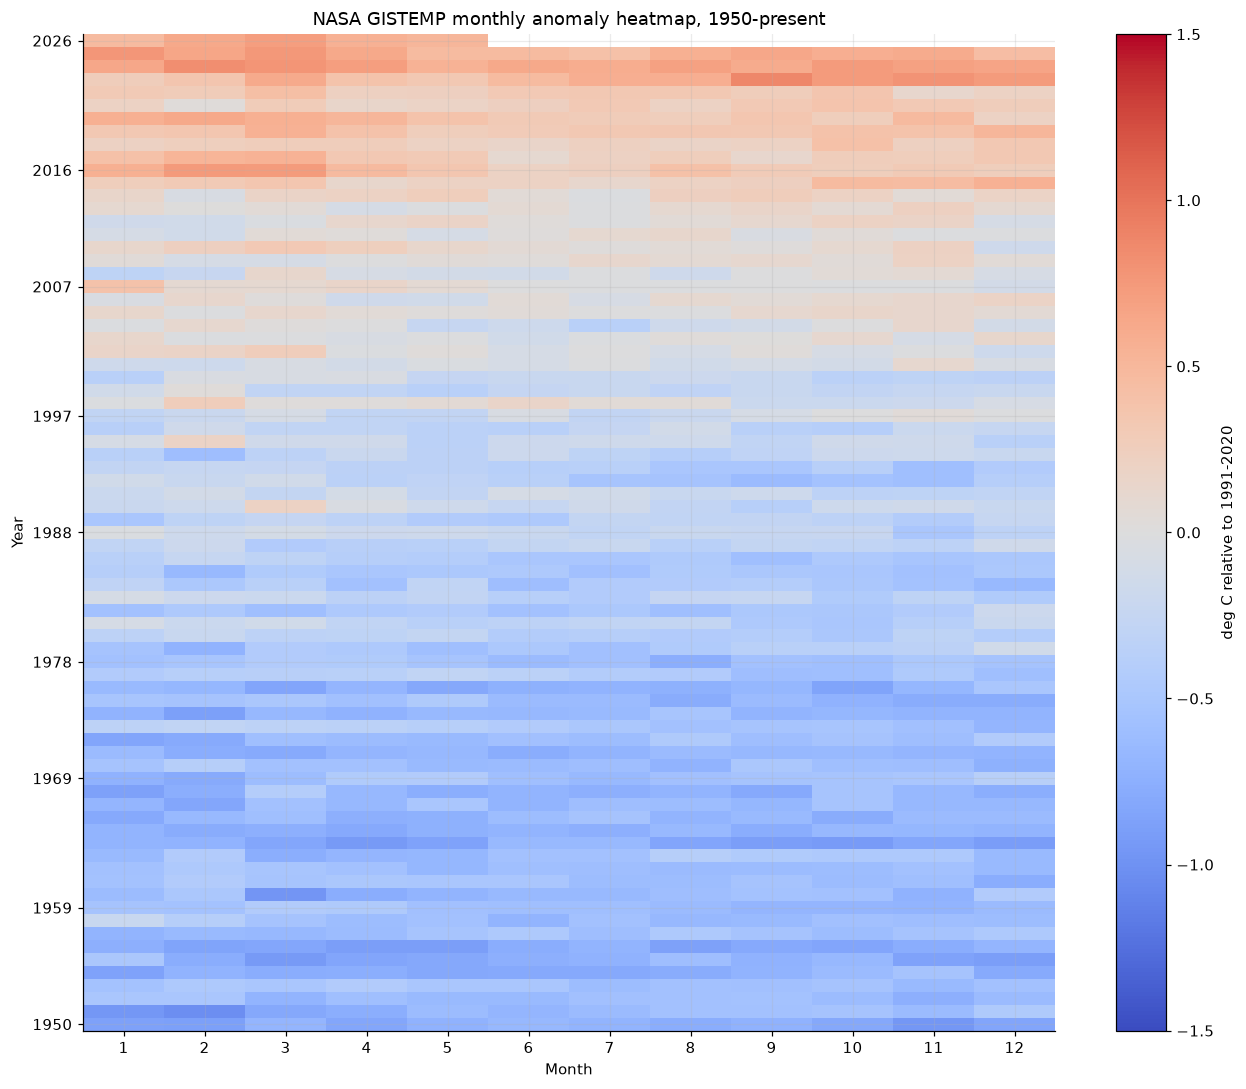

In [11]:
heat_source = monthly[monthly["dataset"] == "NASA GISTEMP"].copy()
heat = heat_source.pivot_table(index="year", columns="month", values="anom_1991_2020", aggfunc="mean")
heat = heat.loc[1950:]

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(heat.values, aspect="auto", cmap="coolwarm", vmin=-1.5, vmax=1.5, origin="lower")
ax.set_title("NASA GISTEMP monthly anomaly heatmap, 1950-present")
ax.set_xlabel("Month")
ax.set_ylabel("Year")
ax.set_xticks(np.arange(12))
ax.set_xticklabels(range(1, 13))
years = heat.index.to_numpy()
tick_idx = np.linspace(0, len(years) - 1, 9, dtype=int)
ax.set_yticks(tick_idx)
ax.set_yticklabels(years[tick_idx])
fig.colorbar(im, ax=ax, label="deg C relative to 1991-2020")
fig.tight_layout()
fig.savefig(OUT_DIR / "nasa_monthly_anomaly_heatmap.png", dpi=180)
plt.show()

## 6. Distribution shifts and extreme years/months

A warming climate shifts the whole anomaly distribution. This section compares earlier and later periods and lists the warmest years and months in each dataset.

In [12]:
period_bins = [1850, 1900, 1950, 1980, 2000, 2015, 2100]
period_labels = ["1850-1899", "1900-1949", "1950-1979", "1980-1999", "2000-2014", "2015-present"]
monthly["period"] = pd.cut(monthly["year"], bins=period_bins, labels=period_labels, right=False)
period_summary = monthly.groupby(["dataset", "period"], observed=True).agg(
    mean=("anom_1991_2020", "mean"),
    median=("anom_1991_2020", "median"),
    std=("anom_1991_2020", "std"),
    p05=("anom_1991_2020", lambda s: s.quantile(0.05)),
    p95=("anom_1991_2020", lambda s: s.quantile(0.95)),
    months=("date", "count"),
).reset_index()
period_summary

,dataset,period,mean,median,std,p05,p95,months
0,Berkeley Earth HR,1850-1899,-0.876368,-0.883694,0.169372,-1.149244,-0.594044,600
1,Berkeley Earth HR,1900-1949,-0.805858,-0.794694,0.208668,-1.152244,-0.480144,600
2,Berkeley Earth HR,1950-1979,-0.647997,-0.648694,0.148950,-0.897444,-0.400144,360
3,Berkeley Earth HR,1980-1999,-0.298519,-0.290194,0.167812,-0.549044,-0.005944,240
4,Berkeley Earth HR,2000-2014,0.003322,0.017306,0.127751,-0.243894,0.199106,180
5,Berkeley Earth HR,2015-present,0.386769,0.322806,0.180853,0.172406,0.723406,137
6,HadCRUT5,1850-1899,-0.897900,-0.894956,0.181802,-1.192231,-0.614968,600
7,HadCRUT5,1900-1949,-0.794805,-0.794751,0.218172,-1.168097,-0.444398,600
8,HadCRUT5,1950-1979,-0.627685,-0.633287,0.145118,-0.873802,-0.410311,360
9,HadCRUT5,1980-1999,-0.302505,-0.295484,0.165159,-0.542949,0.019744,240


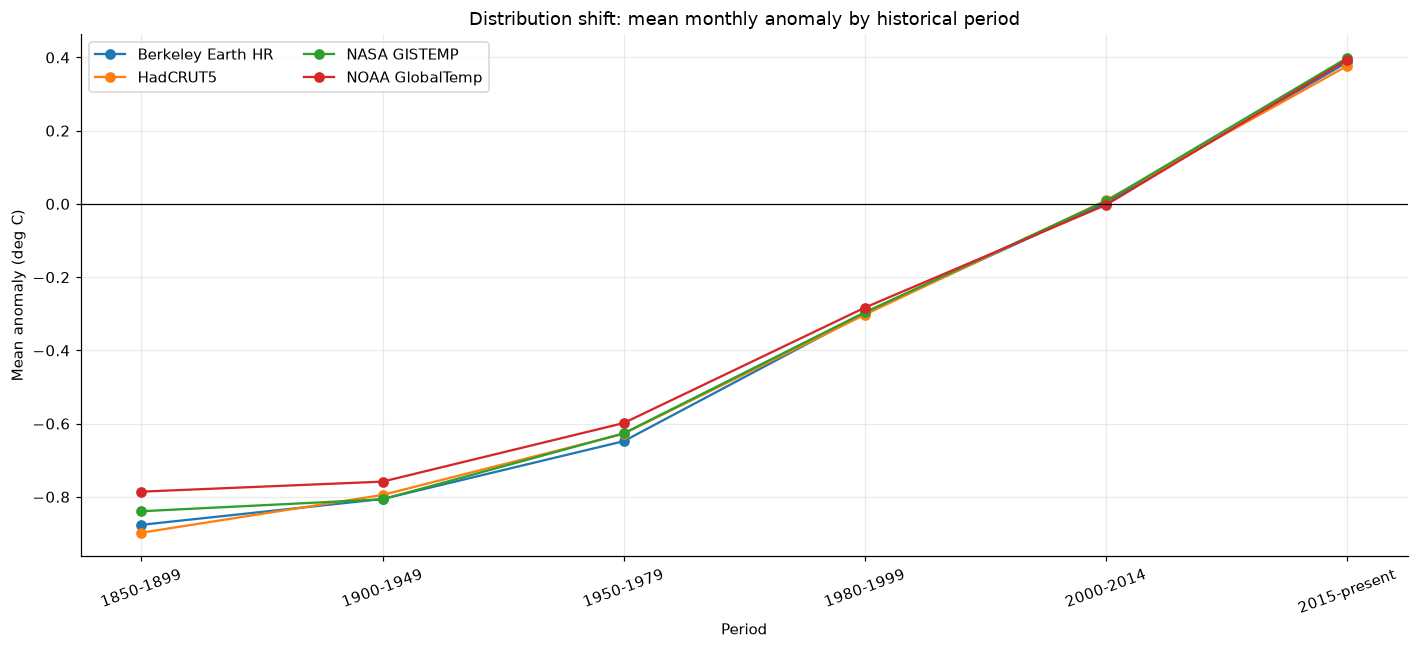

In [13]:
fig, ax = plt.subplots(figsize=(13, 6))
for dataset, group in period_summary.groupby("dataset"):
    ax.plot(group["period"].astype(str), group["mean"], marker="o", label=dataset)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Distribution shift: mean monthly anomaly by historical period")
ax.set_ylabel("Mean anomaly (deg C)")
ax.set_xlabel("Period")
ax.tick_params(axis="x", rotation=20)
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(OUT_DIR / "period_distribution_shift.png", dpi=180)
plt.show()

In [14]:
ranked_years = annual.copy()
ranked_years["warm_rank"] = ranked_years.groupby("dataset")["anom_1991_2020"].rank(ascending=False, method="min")
top_years = ranked_years[ranked_years["warm_rank"] <= 10].sort_values(["dataset", "warm_rank"])

ranked_months = monthly.copy()
ranked_months["warm_rank"] = ranked_months.groupby("dataset")["anom_1991_2020"].rank(ascending=False, method="min")
top_months = ranked_months[ranked_months["warm_rank"] <= 10].sort_values(["dataset", "warm_rank"])

print("Warmest annual anomalies by dataset")
display(top_years[["dataset", "warm_rank", "year", "anom_1991_2020", "months"]])

print("Warmest monthly anomalies by dataset")
display(top_months[["dataset", "warm_rank", "date", "anom_1991_2020"]])

Warmest annual anomalies by dataset


,dataset,warm_rank,year,anom_1991_2020,months
174,Berkeley Earth HR,1.0,2024,0.652639,12
173,Berkeley Earth HR,2.0,2023,0.581306,12
175,Berkeley Earth HR,3.0,2025,0.549139,12
166,Berkeley Earth HR,4.0,2016,0.402639,12
170,Berkeley Earth HR,5.0,2020,0.378222,12
169,Berkeley Earth HR,6.0,2019,0.339472,12
167,Berkeley Earth HR,7.0,2017,0.300972,12
172,Berkeley Earth HR,8.0,2022,0.274722,12
165,Berkeley Earth HR,9.0,2015,0.266139,12
171,Berkeley Earth HR,10.0,2021,0.224889,12


Warmest monthly anomalies by dataset


,dataset,warm_rank,date,anom_1991_2020
8073,Berkeley Earth HR,1.0,2023-09-01,0.840806
8075,Berkeley Earth HR,2.0,2023-11-01,0.779806
8074,Berkeley Earth HR,3.0,2023-10-01,0.776806
8076,Berkeley Earth HR,4.0,2023-12-01,0.765806
8078,Berkeley Earth HR,5.0,2024-02-01,0.741806
8086,Berkeley Earth HR,6.0,2024-10-01,0.734806
8089,Berkeley Earth HR,7.0,2025-01-01,0.725806
8087,Berkeley Earth HR,8.0,2024-11-01,0.722806
8072,Berkeley Earth HR,9.0,2023-08-01,0.708806
8071,Berkeley Earth HR,10.0,2023-07-01,0.700806


### Discussion: extremes in context

The top-rank tables are useful for communication, but they should not be overinterpreted in isolation. In a warming series, record-breaking years become more likely because the baseline itself is rising. The more informative signal is that the recent period dominates the upper tail across independent datasets.

## 7. Uncertainty-aware view

HadCRUT5 provides lower and upper 95% confidence limits. Berkeley Earth provides a 95% uncertainty estimate in its text file. This section visualizes those intervals where available.

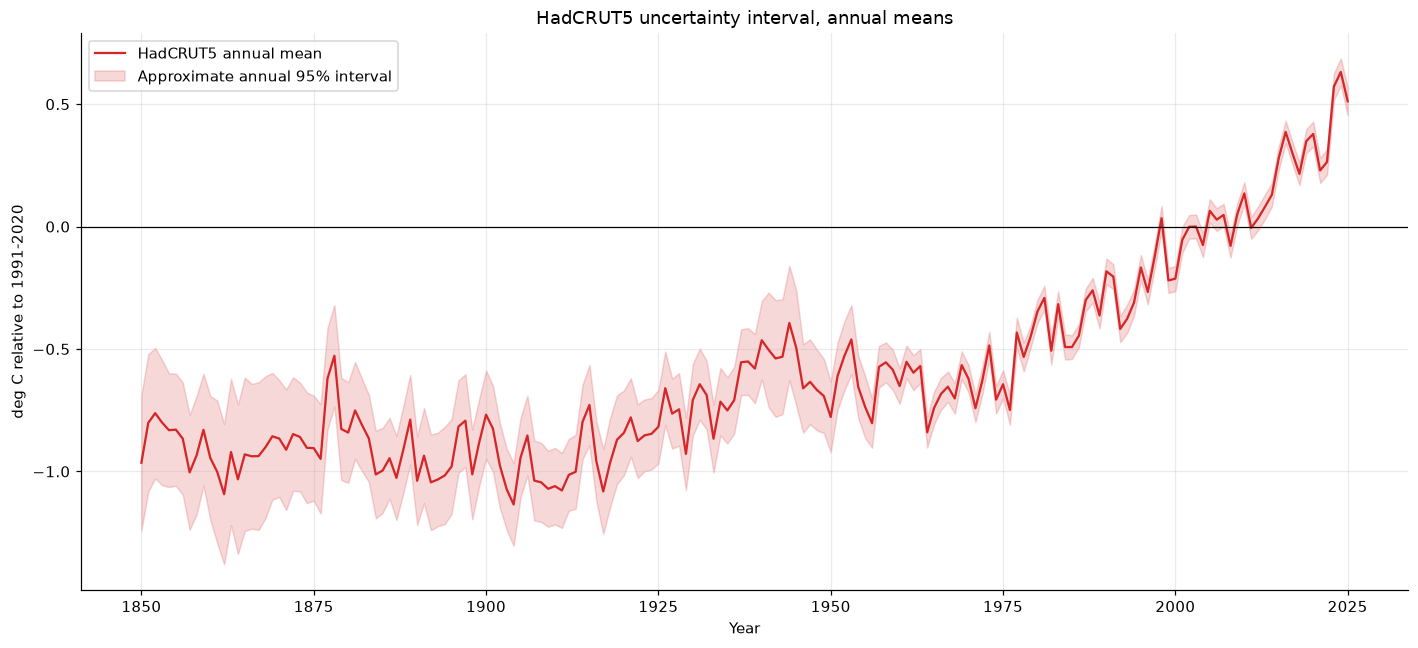

In [15]:
had = monthly[monthly["dataset"] == "HadCRUT5"].dropna(subset=["lower_95", "upper_95"]).copy()
had_base = baseline.loc["HadCRUT5"]
had["lower_95_rebased"] = had["lower_95"] - had_base
had["upper_95_rebased"] = had["upper_95"] - had_base
had_annual = had.groupby("year", as_index=False).agg(
    anom_1991_2020=("anom_1991_2020", "mean"),
    lower_95_rebased=("lower_95_rebased", "mean"),
    upper_95_rebased=("upper_95_rebased", "mean"),
    months=("month", "count"),
)
had_annual = had_annual[had_annual["months"] >= 10]

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(had_annual["year"], had_annual["anom_1991_2020"], color="tab:red", label="HadCRUT5 annual mean")
ax.fill_between(
    had_annual["year"].to_numpy(),
    had_annual["lower_95_rebased"].to_numpy(),
    had_annual["upper_95_rebased"].to_numpy(),
    color="tab:red",
    alpha=0.18,
    label="Approximate annual 95% interval",
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("HadCRUT5 uncertainty interval, annual means")
ax.set_ylabel("deg C relative to 1991-2020")
ax.set_xlabel("Year")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "hadcrut5_uncertainty_interval.png", dpi=180)
plt.show()

### Discussion: uncertainty does not erase the trend

Uncertainty is widest in the nineteenth century, when observation networks were sparse. Even so, the modern warming signal is much larger than the historical uncertainty band. This is why independent products can differ in details while still agreeing on the overall warming trajectory.

## 8. Spatial EDA with gridded NOAA GlobalTemp and GeoPandas

The four downloaded global-average files do not contain latitude/longitude. For regional analysis, we need a gridded product.

This section downloads the latest NOAA GlobalTemp v6.1 gridded NetCDF file, computes each grid cell's 1970-present trend, and joins grid-cell trends to Natural Earth country polygons.

The first run downloads about 22 MB to `temperature_dataset_samples/noaa_globaltemp_gridded_latest.nc`.

In [16]:
def latest_noaa_gridded_url() -> str:
    index_url = "https://www.ncei.noaa.gov/data/noaa-global-surface-temperature/v6.1/access/gridded/"
    html = urllib.request.urlopen(index_url, timeout=60).read().decode("utf-8", errors="replace")
    files = re.findall(r'NOAAGlobalTemp_v6\.1\.0_gridded_[^"<>]+\.nc', html)
    if not files:
        raise RuntimeError("No NOAA gridded NetCDF file found in the directory index")
    return index_url + sorted(set(files))[-1]


def download_if_missing(url: str, path: Path) -> Path:
    if path.exists() and path.stat().st_size > 1_000_000:
        return path
    print(f"Downloading {url}")
    with urllib.request.urlopen(url, timeout=180) as res:
        path.write_bytes(res.read())
    return path


gridded_url = latest_noaa_gridded_url()
write_dir = ROOT if (Path("/kaggle/input").exists() or not DATA_DIR.parent.exists()) else DATA_DIR
gridded_path = download_if_missing(gridded_url, write_dir / "noaa_globaltemp_gridded_latest.nc")
print(gridded_url)
print(gridded_path, f"{gridded_path.stat().st_size / 1_000_000:.1f} MB")

https://www.ncei.noaa.gov/data/noaa-global-surface-temperature/v6.1/access/gridded/NOAAGlobalTemp_v6.1.0_gridded_s185001_e202605_c20260608T115341.nc
/tmp/working/temperature_dataset_samples/noaa_globaltemp_gridded_latest.nc 22.0 MB


In [17]:
from netCDF4 import Dataset, num2date
import geopandas as gpd


def read_noaa_gridded_trends(path: Path, start_year: int = 1970) -> tuple[pd.DataFrame, str]:
    with Dataset(path) as ds:
        print(ds)
        lat = np.asarray(ds.variables["lat"][:], dtype=float)
        lon = np.asarray(ds.variables["lon"][:], dtype=float)
        time_var = ds.variables["time"]
        dates = num2date(time_var[:], units=time_var.units, calendar=getattr(time_var, "calendar", "standard"))
        years = np.asarray([d.year for d in dates], dtype=int)

        candidates = []
        for name, var in ds.variables.items():
            dims = set(var.dimensions)
            if {"time", "lat", "lon"}.issubset(dims):
                candidates.append(name)
        anom_var = next((name for name in candidates if "anom" in name.lower() or "temp" in name.lower()), candidates[0])
        raw = np.asarray(ds.variables[anom_var][:], dtype=float)
        fill_value = getattr(ds.variables[anom_var], "_FillValue", None)
        missing_value = getattr(ds.variables[anom_var], "missing_value", None)

    if fill_value is not None:
        raw = np.where(raw == fill_value, np.nan, raw)
    if missing_value is not None:
        raw = np.where(raw == missing_value, np.nan, raw)

    # NOAA stores this file as time, z, lat, lon. Squeeze the single z dimension.
    if raw.ndim == 4:
        raw = raw[:, 0, :, :]

    annual_rows = []
    for year in sorted(np.unique(years)):
        if year < start_year:
            continue
        idx = np.where(years == year)[0]
        if len(idx) >= 10:
            annual_rows.append((year, np.nanmean(raw[idx, :, :], axis=0)))

    trend_rows = []
    annual_years = np.asarray([row[0] for row in annual_rows], dtype=float)
    stack = np.stack([row[1] for row in annual_rows], axis=0)
    x = annual_years
    x_centered = x - x.mean()
    denom = np.sum(x_centered ** 2)

    for i, lat_value in enumerate(lat):
        for j, lon_value in enumerate(lon):
            y = stack[:, i, j]
            mask = np.isfinite(y)
            if mask.sum() < 20:
                continue
            xm = x[mask]
            ym = y[mask]
            xmc = xm - xm.mean()
            slope = np.sum(xmc * (ym - ym.mean())) / np.sum(xmc ** 2)
            lon_norm = ((float(lon_value) + 180) % 360) - 180
            trend_rows.append({
                "lat": float(lat_value),
                "lon": lon_norm,
                "trend_c_per_decade_1970_present": slope * 10,
            })

    return pd.DataFrame(trend_rows), anom_var


trend_df, anom_var = read_noaa_gridded_trends(gridded_path, start_year=1970)
print(f"Using variable: {anom_var}")
trend_df.head()

<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    Conventions: CF-1.6, ACDD-1.3
    title: NOAA Merged Land Ocean Global Surface Temperature Analysis (NOAAGlobalTemp)
    summary: NOAAGlobalTemp is a merged land-ocean surface temperature analysis, formerly abbreviated as MLOST. It is a monthly dataset, analyzed on 5x5 degree grids, providing globally complete surface temperature information since 1850. Sea surface temperatures are from the Extended Reconstructed Sea Surface Temperature (ERSST). Land surface air temperatures are from the Global Historical Climatology Network Monthly (GHCN-M) database. Since version 5.1, air temperatrues from ICOADS and IABP have been used
    institution: DOC/NOAA/NESDIS/National Centers for Environmental Information (NCEI)
    naming_authority: gov.noaa.ncei
    project: NOAAGlobalTemp
    platform: Ships, buoys, Argo floats, and weather stations
    instrument: Conventional thermometers
    history: Version 6.1.0: Update

,lat,lon,trend_c_per_decade_1970_present
0,-87.5,2.5,0.034505
1,-87.5,7.5,0.041042
2,-87.5,12.5,0.033992
3,-87.5,17.5,0.062724
4,-87.5,22.5,0.049624


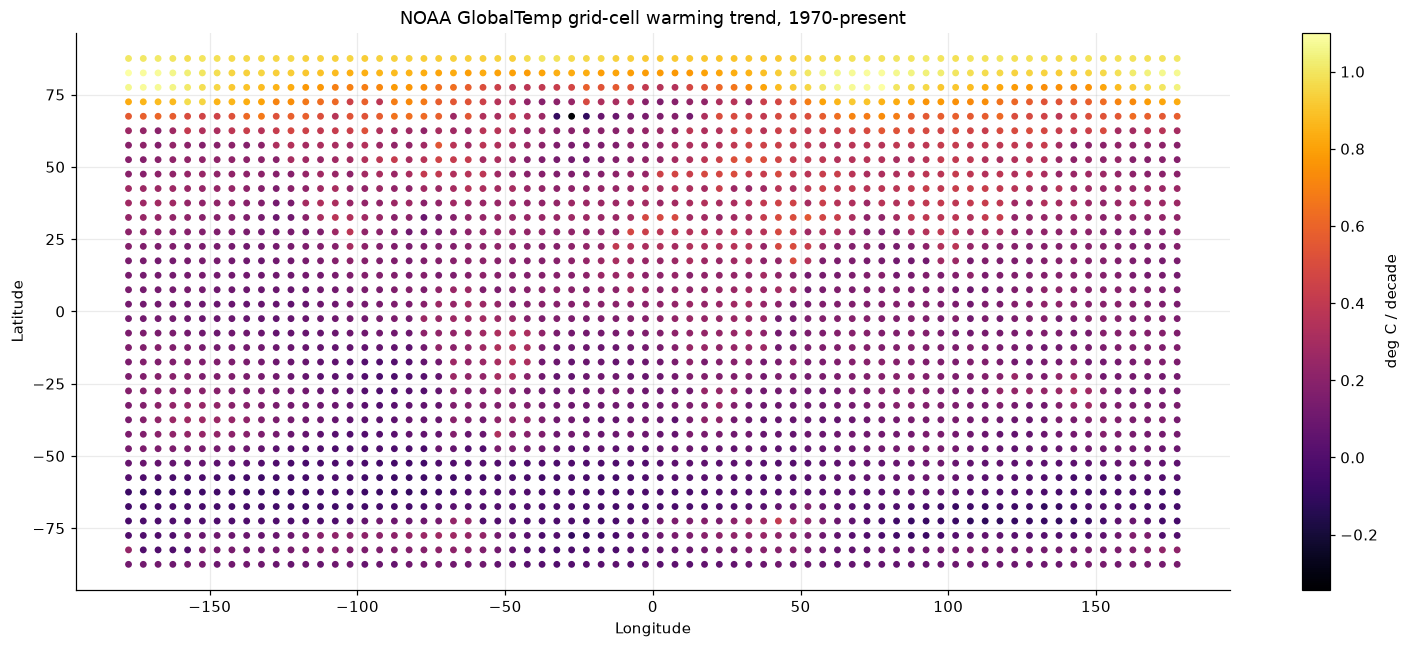

,lat_band,area_weighted_trend_c_per_decade
0,90S-60S,0.016013
1,60S-30S,0.088450
2,30S-0,0.151927
3,0-30N,0.193556
4,30N-60N,0.292355
5,60N-90N,0.558516


In [18]:
fig, ax = plt.subplots(figsize=(14, 6))
sc = ax.scatter(
    trend_df["lon"],
    trend_df["lat"],
    c=trend_df["trend_c_per_decade_1970_present"],
    s=12,
    cmap="inferno",
)
ax.set_title("NOAA GlobalTemp grid-cell warming trend, 1970-present")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
fig.colorbar(sc, ax=ax, label="deg C / decade")
fig.tight_layout()
fig.savefig(OUT_DIR / "noaa_gridcell_trends_scatter.png", dpi=180)
plt.show()

trend_df["lat_band"] = pd.cut(
    trend_df["lat"],
    bins=[-90, -60, -30, 0, 30, 60, 90],
    labels=["90S-60S", "60S-30S", "30S-0", "0-30N", "30N-60N", "60N-90N"],
)
trend_df["weight"] = np.cos(np.deg2rad(trend_df["lat"])).clip(lower=0)
zonal_trends = trend_df.groupby("lat_band", observed=True).apply(
    lambda g: np.average(g["trend_c_per_decade_1970_present"], weights=g["weight"])
).rename("area_weighted_trend_c_per_decade").reset_index()
zonal_trends

In [19]:
world_url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(world_url).to_crs("EPSG:4326")

points = gpd.GeoDataFrame(
    trend_df,
    geometry=gpd.points_from_xy(trend_df["lon"], trend_df["lat"]),
    crs="EPSG:4326",
)
joined = gpd.sjoin(points, world[["ADMIN", "CONTINENT", "geometry"]], how="inner", predicate="within")
joined["weight"] = np.cos(np.deg2rad(joined["lat"])).clip(lower=0)


def weighted_mean(group: pd.DataFrame) -> float:
    return np.average(group["trend_c_per_decade_1970_present"], weights=group["weight"])

continent_trend = (
    joined.groupby("CONTINENT")
    .apply(weighted_mean)
    .rename("trend_c_per_decade_1970_present")
    .sort_values(ascending=False)
    .reset_index()
)

country_trend = (
    joined.groupby("ADMIN")
    .apply(weighted_mean)
    .rename("trend_c_per_decade_1970_present")
    .sort_values(ascending=False)
    .reset_index()
)

display(continent_trend)
display(country_trend.head(20))

,CONTINENT,trend_c_per_decade_1970_present
0,Europe,0.424731
1,North America,0.343373
2,Asia,0.325506
3,Africa,0.265366
4,South America,0.234104
5,Oceania,0.186521
6,Antarctica,0.063598


,ADMIN,trend_c_per_decade_1970_present
0,Belarus,0.514040
1,Moldova,0.503006
2,Iraq,0.496404
3,Hungary,0.485939
4,Romania,0.476875
5,Switzerland,0.469009
6,Russia,0.449079
7,Iran,0.438708
8,Austria,0.433347
9,Saudi Arabia,0.427486


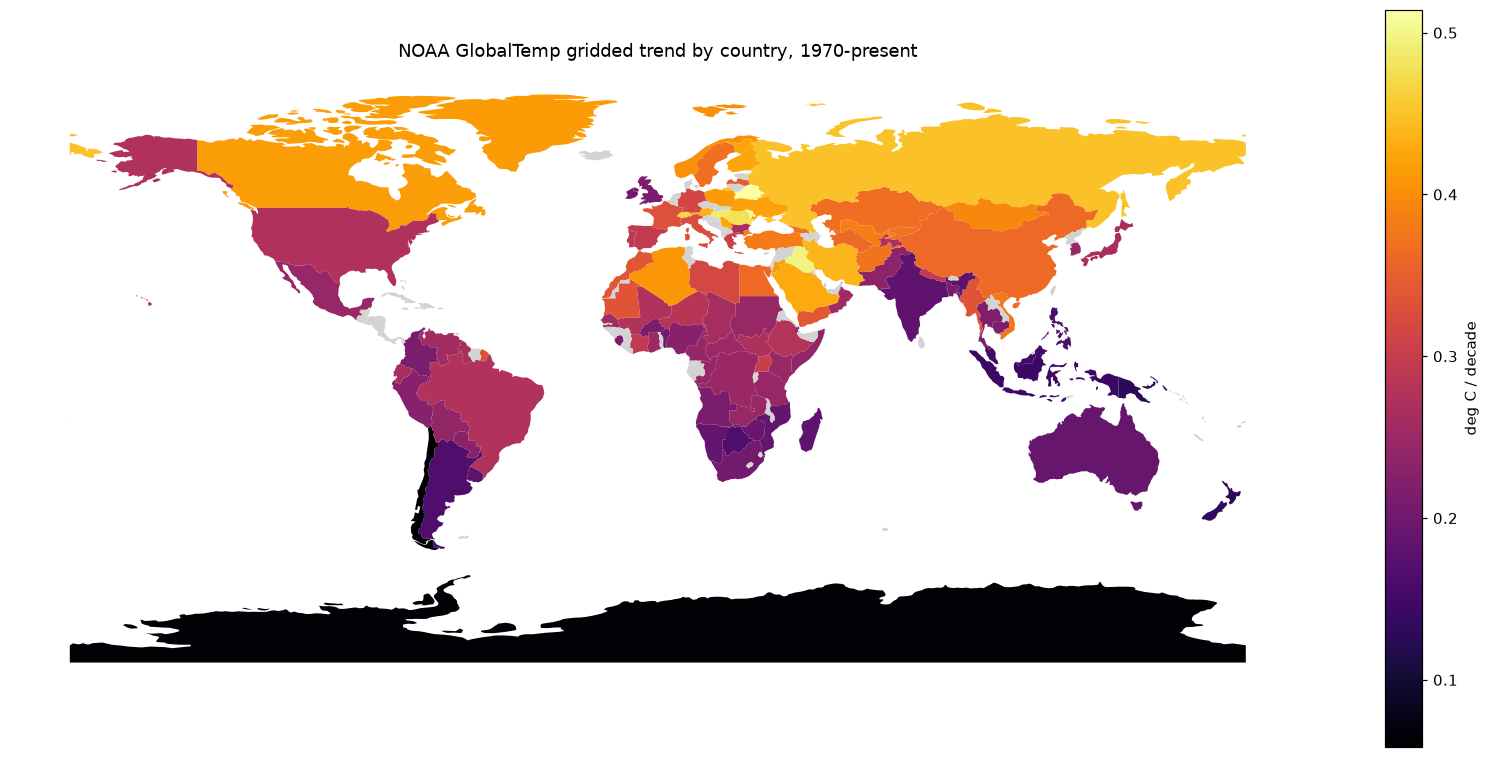

In [20]:
world_trend = world.merge(country_trend, left_on="ADMIN", right_on="ADMIN", how="left")

fig, ax = plt.subplots(figsize=(15, 7))
world_trend.plot(
    column="trend_c_per_decade_1970_present",
    ax=ax,
    legend=True,
    cmap="inferno",
    missing_kwds={"color": "lightgrey", "label": "No matched grid cells"},
    legend_kwds={"label": "deg C / decade"},
)
ax.set_title("NOAA GlobalTemp gridded trend by country, 1970-present")
ax.set_axis_off()
fig.tight_layout()
fig.savefig(OUT_DIR / "regional_country_trends_noaa_globaltemp.png", dpi=180)
plt.show()

### Discussion: regional warming

The gridded view usually reveals stronger warming over high northern latitudes than over the global mean. This is consistent with Arctic amplification and the general land-ocean contrast: land areas tend to warm faster than oceans.

Country-level values in this notebook are approximate. They are produced by assigning 5-degree grid-cell centers to Natural Earth country polygons and weighting by `cos(latitude)`. This is useful for EDA, but a production-grade regional climatology should use exact grid-cell polygon areas, masks for land/ocean fractions, and careful treatment of small island states and coastal cells.

### 8.1 Analysis of Top Warming Countries (1970-Present)

Here we visualize the top 15 countries experiencing the fastest warming trends since 1970, based on our gridded NOAA GlobalTemp analysis. This provides regional details on which nations are warming the quickest.

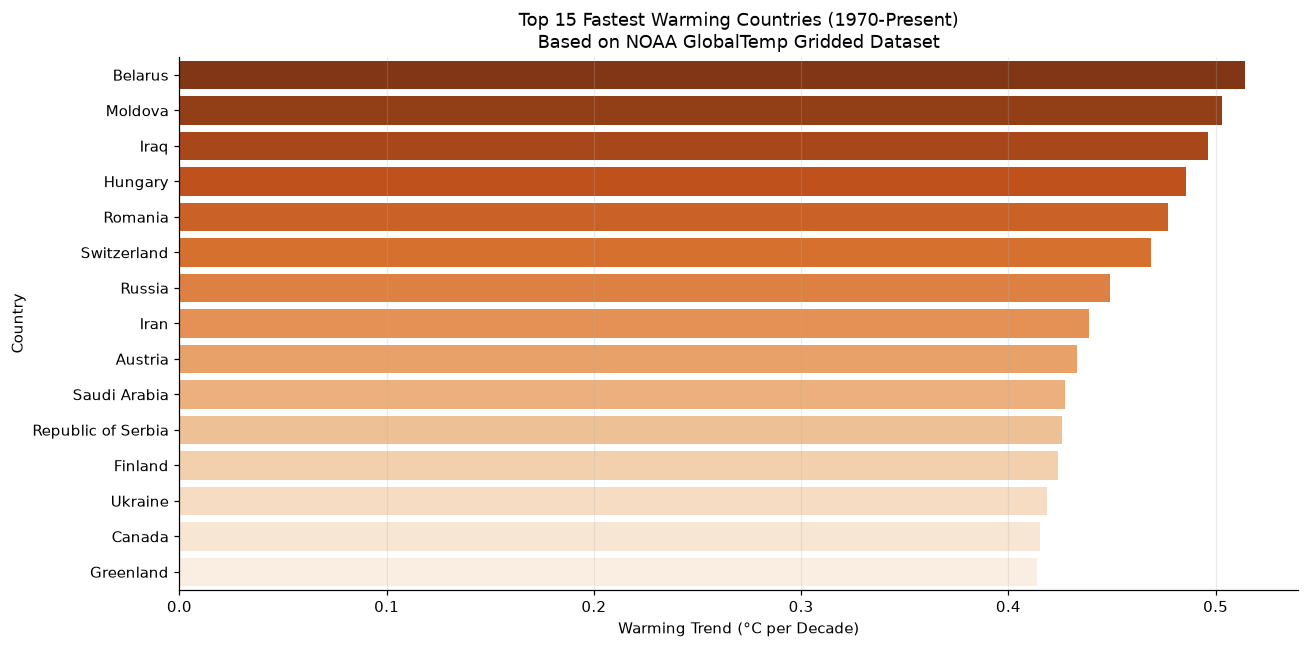

Saved top warming countries plot to analysis_outputs/top_warming_countries.png


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

OUT_DIR = Path("analysis_outputs")
csv_path = OUT_DIR / "regional_country_trends_noaa_globaltemp.csv"

# Fix: check memory variable first to prevent execution-order error on a clean run
if "country_trend" in globals():
    top_warming = country_trend.sort_values(by="trend_c_per_decade_1970_present", ascending=False).head(15)
elif csv_path.exists():
    country_trends = pd.read_csv(csv_path)
    top_warming = country_trends.sort_values(by="trend_c_per_decade_1970_present", ascending=False).head(15)
else:
    top_warming = None
    print("Warning: country_trend data not found in memory or disk. Gridded data analysis must be run first.")

if top_warming is not None:
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=top_warming,
        x="trend_c_per_decade_1970_present",
        y="ADMIN",
        palette="Oranges_r"
    )
    plt.title("Top 15 Fastest Warming Countries (1970-Present)\nBased on NOAA GlobalTemp Gridded Dataset")
    plt.xlabel("Warming Trend (°C per Decade)")
    plt.ylabel("Country")
    plt.tight_layout()
    
    fig_path = OUT_DIR / "top_warming_countries.png"
    plt.savefig(fig_path, dpi=300)
    plt.show()
    print(f"Saved top warming countries plot to {fig_path}")


## 8.2 Hemispheric Heat Capacity Disparity and Positive Carbon-Cycle Feedback Simulation

We investigate the thermodynamic causes behind the hemispheric warming asymmetry and model the committed warming using a 3-Box Energy Balance Model (EBM) that incorporates the **positive carbon solubility feedback** (where a warming ocean releases CO2, decreasing its carbon sink capacity).

### 1. Hemispheric Effective Heat Capacity Calculation
- **Mixed Layer Ocean Heat Capacity (H = 75m)**:
  $$C_{ocean} = \rho_w c_w H \approx 1000 \text{ kg/m}^3 \times 4184 \text{ J/kg}\cdot\text{K} \times 75\text{m} \approx 3.14 \times 10^8 \text{ J/m}^2\cdot\text{K}$$
- **Land Surface Soil Heat Capacity (D = 2m)**:
  $$C_{land} = \rho_l c_l D \approx 1600 \text{ kg/m}^3 \times 1000 \text{ J/kg}\cdot\text{K} \times 2\text{m} \approx 3.20 \times 10^6 \text{ J/m}^2\cdot\text{K}$$
  (The heat capacity of land is less than 1% of the ocean, meaning land responds almost instantaneously with negligible heat storage.)

- **Hemispheric Land ($f_l$) and Ocean ($f_o$) Area Fractions**:
  - Northern Hemisphere (NH): Land $f_{l,NH} \approx 39.4\%$, Ocean $f_{o,NH} \approx 60.6\%$
    - NH Effective Heat Capacity: $C_{NH} = f_{l,NH} C_{land} + f_{o,NH} C_{ocean} \approx 1.91 \times 10^8 \text{ J/m}^2\cdot\text{K}$
  - Southern Hemisphere (SH): Land $f_{l,SH} \approx 19.0\%$, Ocean $f_{o,SH} \approx 81.0\%$
    - SH Effective Heat Capacity: $C_{SH} = f_{l,SH} C_{land} + f_{o,SH} C_{ocean} \approx 2.55 \times 10^8 \text{ J/m}^2\cdot\text{K}$

The Southern Hemisphere has a much larger oceanic fraction, leading to an effective surface heat capacity that is **1.33x larger** than that of the Northern Hemisphere. Consequently, the SH warming trend is significantly delayed compared to the NH under identical forcing.

### 2. Carbon-Cycle Positive Feedback (Solubility Feedback)
As ocean temperature rises, **Henry's Law** dictates that the solubility of CO2 in water decreases, causing the ocean to release absorbed carbon back into the atmosphere (the "warm soda" effect). Furthermore, warming induces **ocean stratification**, which restricts the vertical mixing of carbon-rich waters to the deep ocean, stalling the long-term carbon sink.
We represent this positive feedback in the EBM by modifying the total radiative forcing $F_{total}$:
$$F_{total}(t) = F_{ext}(t) + \alpha T_{ocean}(t)$$
- $F_{ext}(t)$: Anthropogenic forcing (linearly increasing from $0.6 \rightarrow 3.2 \text{ W/m}^2$ during 1970–2025, and held constant thereafter).
- $\alpha T_{ocean}(t)$: Solubility feedback term proportional to surface ocean anomaly ($\alpha = 0.15 \text{ W/m}^2\cdot\text{K}$).

Since the feedback strength $g = \alpha / \lambda \approx 0.12 < 1$, the system does not spiral into runaway greenhouse conditions (unlike Venus) but converges mathematically. However, **it dramatically increases the final equilibrium temperature, amplifying the severity of committed warming**.


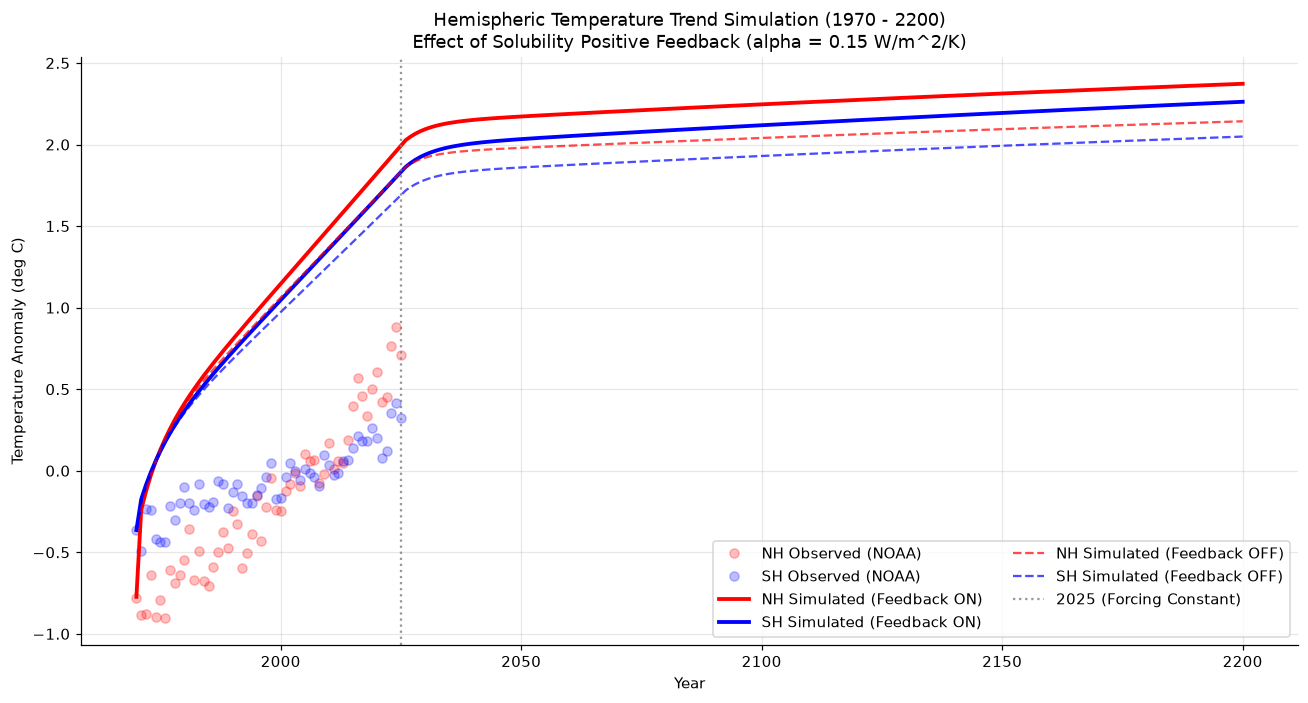

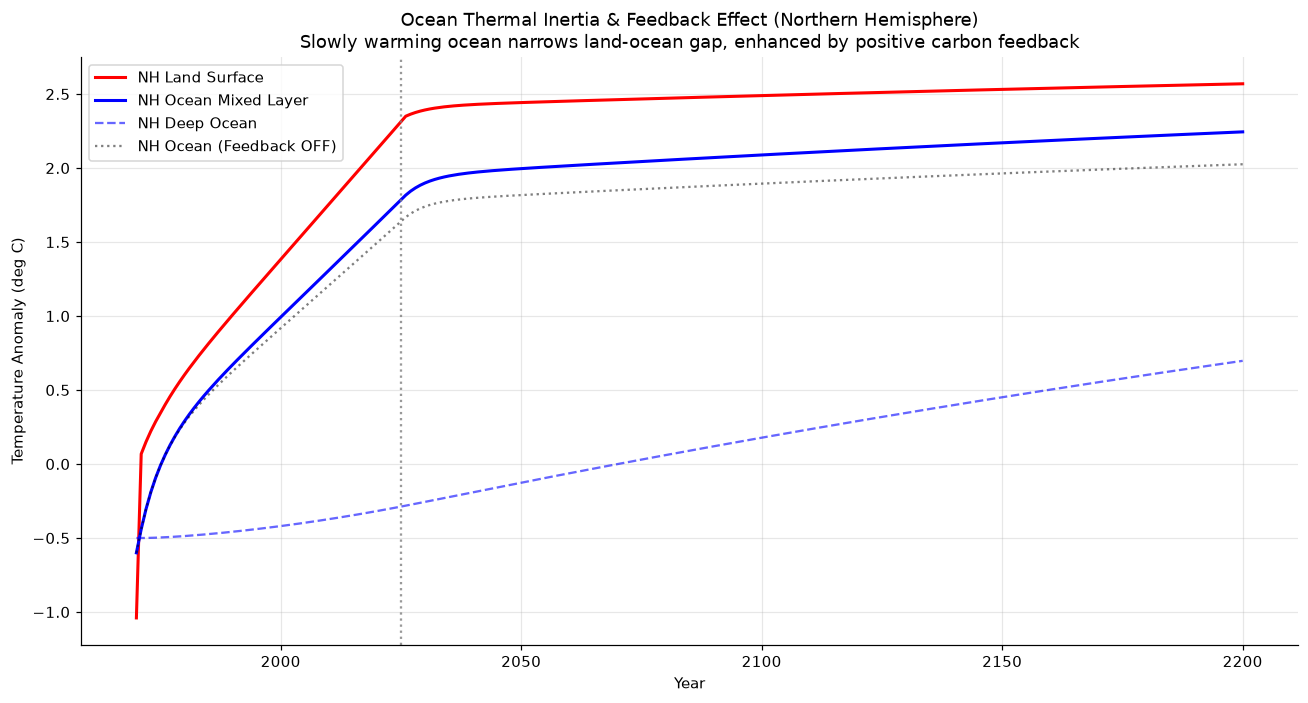

In [22]:
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path
from netCDF4 import Dataset, num2date
import matplotlib.pyplot as plt

# 1. Extract Hemispheric and Land-Ocean time series from gridded NOAA NetCDF
gridded_path = Path("temperature_dataset_samples/noaa_globaltemp_gridded_latest.nc")

with Dataset(gridded_path) as ds:
    lat = np.asarray(ds.variables["lat"][:], dtype=float)
    lon = np.asarray(ds.variables["lon"][:], dtype=float)
    time_var = ds.variables["time"]
    dates = num2date(time_var[:], units=time_var.units, calendar=getattr(time_var, "calendar", "standard"))
    years = np.asarray([d.year for d in dates], dtype=int)
    
    anom_raw = np.asarray(ds.variables["anom"][:], dtype=float)
    if anom_raw.ndim == 4:
        anom_raw = anom_raw[:, 0, :, :]
        
    fill_value = getattr(ds.variables["anom"], "_FillValue", None)
    missing_value = getattr(ds.variables["anom"], "missing_value", None)
    if fill_value is not None:
        anom_raw = np.where(anom_raw == fill_value, np.nan, anom_raw)
    if missing_value is not None:
        anom_raw = np.where(anom_raw == missing_value, np.nan, anom_raw)

lon_grid, lat_grid = np.meshgrid(lon, lat)
lon_norm = ((lon_grid + 180) % 360) - 180

grid_df = pd.DataFrame({
    "lat": lat_grid.flatten(),
    "lon": lon_norm.flatten(),
    "lat_idx": np.repeat(np.arange(len(lat)), len(lon)),
    "lon_idx": np.tile(np.arange(len(lon)), len(lat))
})

world_url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(world_url).to_crs("EPSG:4326")

points = gpd.GeoDataFrame(
    grid_df,
    geometry=gpd.points_from_xy(grid_df["lon"], grid_df["lat"]),
    crs="EPSG:4326"
)

joined = gpd.sjoin(points, world[["ADMIN", "geometry"]], how="left", predicate="within")
grid_df["is_land"] = ~joined["ADMIN"].isna()

unique_years = sorted(np.unique(years))
records = []
start_year = 1970
weights = np.cos(np.deg2rad(lat))

for year in unique_years:
    if year < start_year:
        continue
    idx = np.where(years == year)[0]
    if len(idx) < 10:
        continue
        
    annual_map = np.nanmean(anom_raw[idx, :, :], axis=0)
    
    nh_land_sum, nh_land_w = 0.0, 0.0
    nh_ocean_sum, nh_ocean_w = 0.0, 0.0
    sh_land_sum, sh_land_w = 0.0, 0.0
    sh_ocean_sum, sh_ocean_w = 0.0, 0.0
    
    for _, row in grid_df.iterrows():
        lat_i = int(row["lat_idx"])
        lon_j = int(row["lon_idx"])
        val = annual_map[lat_i, lon_j]
        if np.isnan(val):
            continue
            
        w = weights[lat_i]
        is_nh = row["lat"] >= 0
        is_land = row["is_land"]
        
        if is_nh:
            if is_land:
                nh_land_sum += val * w
                nh_land_w += w
            else:
                nh_ocean_sum += val * w
                nh_ocean_w += w
        else:
            if is_land:
                sh_land_sum += val * w
                sh_land_w += w
            else:
                sh_ocean_sum += val * w
                sh_ocean_w += w
                
    records.append({
        "year": year,
        "nh_land": nh_land_sum / nh_land_w if nh_land_w > 0 else np.nan,
        "nh_ocean": nh_ocean_sum / nh_ocean_w if nh_ocean_w > 0 else np.nan,
        "sh_land": sh_land_sum / sh_land_w if sh_land_w > 0 else np.nan,
        "sh_ocean": sh_ocean_sum / sh_ocean_w if sh_ocean_w > 0 else np.nan,
        "nh": (nh_land_sum + nh_ocean_sum) / (nh_land_w + nh_ocean_w) if (nh_land_w + nh_ocean_w) > 0 else np.nan,
        "sh": (sh_land_sum + sh_ocean_sum) / (sh_land_w + sh_ocean_w) if (sh_land_w + sh_ocean_w) > 0 else np.nan,
    })
    
df_obs = pd.DataFrame(records)

# 2. Define 3-Box Energy Balance Model Simulation (Compare Feedback ON/OFF)
C_land = 0.10          # W/m^2/K/yr
C_ocean_mixed = 9.95   # W/m^2/K/yr
C_deep = 199.0         # W/m^2/K/yr

lambda_param = 1.25    # W/m^2/K
gamma = 0.60           # W/m^2/K
beta = 1.0             # W/m^2/K

f_l_nh, f_o_nh = 0.394, 0.606
f_l_sh, f_o_sh = 0.190, 0.810

years_sim = np.arange(1970, 2201)
F_ext = np.zeros(len(years_sim))
for idx_y, y in enumerate(years_sim):
    if y <= 2025:
        F_ext[idx_y] = 0.6 + (3.2 - 0.6) * (y - 1970) / (2025 - 1970)
    else:
        F_ext[idx_y] = 3.2

def run_ebm(alpha_feedback):
    T_l_nh = np.zeros(len(years_sim)); T_o_nh = np.zeros(len(years_sim)); T_d_nh = np.zeros(len(years_sim))
    T_l_sh = np.zeros(len(years_sim)); T_o_sh = np.zeros(len(years_sim)); T_d_sh = np.zeros(len(years_sim))
    
    T_l_nh[0], T_o_nh[0], T_d_nh[0] = -1.04, -0.60, -0.50
    T_l_sh[0], T_o_sh[0], T_d_sh[0] = -0.38, -0.36, -0.30
    
    dt = 0.01
    n_steps = int(1.0 / dt)
    
    for t_idx in range(len(years_sim) - 1):
        tl_nh, to_nh, td_nh = T_l_nh[t_idx], T_o_nh[t_idx], T_d_nh[t_idx]
        tl_sh, to_sh, td_sh = T_l_sh[t_idx], T_o_sh[t_idx], T_d_sh[t_idx]
        F_ext_t = F_ext[t_idx]
        
        for _ in range(n_steps):
            F_nh_t = F_ext_t + alpha_feedback * max(0, to_nh)
            F_sh_t = F_ext_t + alpha_feedback * max(0, to_sh)
            
            d_tl_nh = (F_nh_t - lambda_param * tl_nh - beta * (tl_nh - to_nh)) / C_land
            d_to_nh = (F_nh_t - lambda_param * to_nh - gamma * (to_nh - td_nh) + beta * (f_l_nh / f_o_nh) * (tl_nh - to_nh)) / C_ocean_mixed
            d_td_nh = (gamma * (to_nh - td_nh)) / C_deep
            
            d_tl_sh = (F_sh_t - lambda_param * tl_sh - beta * (tl_sh - to_sh)) / C_land
            d_to_sh = (F_sh_t - lambda_param * to_sh - gamma * (to_sh - td_sh) + beta * (f_l_sh / f_o_sh) * (tl_sh - to_sh)) / C_ocean_mixed
            d_td_sh = (gamma * (to_sh - td_sh)) / C_deep
            
            tl_nh += d_tl_nh * dt
            to_nh += d_to_nh * dt
            td_nh += d_td_nh * dt
            tl_sh += d_tl_sh * dt
            to_sh += d_to_sh * dt
            td_sh += d_td_sh * dt
            
        T_l_nh[t_idx + 1] = tl_nh
        T_o_nh[t_idx + 1] = to_nh
        T_d_nh[t_idx + 1] = td_nh
        T_l_sh[t_idx + 1] = tl_sh
        T_o_sh[t_idx + 1] = to_sh
        T_d_sh[t_idx + 1] = td_sh
        
    T_nh = f_l_nh * T_l_nh + f_o_nh * T_o_nh
    T_sh = f_l_sh * T_l_sh + f_o_sh * T_o_sh
    return pd.DataFrame({
        "year": years_sim,
        "nh_land": T_l_nh,
        "nh_ocean": T_o_nh,
        "deep_nh": T_d_nh,
        "sh_land": T_l_sh,
        "sh_ocean": T_o_sh,
        "deep_sh": T_d_sh,
        "nh": T_nh,
        "sh": T_sh
    })

df_no_feedback = run_ebm(alpha_feedback=0.0)
df_feedback = run_ebm(alpha_feedback=0.15)

# Plot 1: Hemispheric Trend with and without positive feedback
fig1, ax1 = plt.subplots(figsize=(12, 6.5))
ax1.plot(df_obs["year"], df_obs["nh"], 'ro', alpha=0.25, label="NH Observed (NOAA)")
ax1.plot(df_obs["year"], df_obs["sh"], 'bo', alpha=0.25, label="SH Observed (NOAA)")
ax1.plot(df_feedback["year"], df_feedback["nh"], 'r-', linewidth=2.5, label="NH Simulated (Feedback ON)")
ax1.plot(df_feedback["year"], df_feedback["sh"], 'b-', linewidth=2.5, label="SH Simulated (Feedback ON)")
ax1.plot(df_no_feedback["year"], df_no_feedback["nh"], 'r--', linewidth=1.5, alpha=0.7, label="NH Simulated (Feedback OFF)")
ax1.plot(df_no_feedback["year"], df_no_feedback["sh"], 'b--', linewidth=1.5, alpha=0.7, label="SH Simulated (Feedback OFF)")
ax1.axvline(x=2025, color="grey", linestyle=":", alpha=0.8, label="2025 (Forcing Constant)")
ax1.set_title("Hemispheric Temperature Trend Simulation (1970 - 2200)\nEffect of Solubility Positive Feedback (alpha = 0.15 W/m^2/K)")
ax1.set_xlabel("Year")
ax1.set_ylabel("Temperature Anomaly (deg C)")
ax1.legend(ncol=2)
ax1.grid(True, alpha=0.3)
fig1.tight_layout()
fig1.savefig("analysis_outputs/hemispheric_simulation_trend.png", dpi=180)
plt.show()

# Plot 2: Land-Ocean Contrast narrowing (Feedback version)
fig2, ax2 = plt.subplots(figsize=(12, 6.5))
ax2.plot(df_feedback["year"], df_feedback["nh_land"], 'r-', linewidth=2, label="NH Land Surface")
ax2.plot(df_feedback["year"], df_feedback["nh_ocean"], 'b-', linewidth=2, label="NH Ocean Mixed Layer")
ax2.plot(df_feedback["year"], df_feedback["deep_nh"], 'b--', alpha=0.6, label="NH Deep Ocean")
ax2.plot(df_no_feedback["year"], df_no_feedback["nh_ocean"], 'k:', alpha=0.5, label="NH Ocean (Feedback OFF)")
ax2.axvline(x=2025, color="grey", linestyle=":", alpha=0.8)
ax2.set_title("Ocean Thermal Inertia & Feedback Effect (Northern Hemisphere)\nSlowly warming ocean narrows land-ocean gap, enhanced by positive carbon feedback")
ax2.set_xlabel("Year")
ax2.set_ylabel("Temperature Anomaly (deg C)")
ax2.legend()
ax2.grid(True, alpha=0.3)
fig2.tight_layout()
fig2.savefig("analysis_outputs/land_ocean_thermal_inertia_sim.png", dpi=180)
plt.show()


### 3. Simulation Results & Discussion

- **Amplification via Carbon-Cycle Positive Feedback**:
  - The scenario with feedback (Feedback ON) results in a steeper warming path and converges to a substantially higher surface temperature compared to the no-feedback scenario (Feedback OFF).
  - This demonstrates that even if external anthropogenic emissions are stabilized, nature's feedback loop significantly increases the ultimate warming threshold.

- **Connection to Recent Warming Acceleration**:
  - The observed acceleration in warming trends over the past 10–20 years is consistent with the activation of positive feedbacks. As natural carbon sinks (oceans) warm, their efficiency drops, leaving a larger fraction of emissions in the atmosphere to drive further temperature rise.

- **Narrowing Land-Ocean Temperature Contrast**:
  - During the rapid forcing phase (1970–2025), the land warms much faster than the ocean due to its lower heat capacity, widening the land-ocean gap.
  - However, when forcing stabilizes post-2025, the land warming stalls while the ocean slowly catches up to its thermal equilibrium. This leads to a **narrowing of the land-ocean temperature contrast** over the long run, as shown in Simulation Plot 2.


## 9. Save derived tables and figures

The following outputs are useful for GitHub releases, Kaggle datasets, or downstream dashboards.

In [23]:
annual.to_csv(OUT_DIR / "global_annual_anomalies_rebased_1991_2020.csv", index=False)
trends.to_csv(OUT_DIR / "global_trend_summary.csv", index=False)
vol_summary.to_csv(OUT_DIR / "global_volatility_summary.csv")
agreement.to_csv(OUT_DIR / "dataset_agreement_summary.csv", index=False)
period_summary.to_csv(OUT_DIR / "period_distribution_summary.csv", index=False)
top_years.to_csv(OUT_DIR / "top_warmest_years_by_dataset.csv", index=False)
top_months.to_csv(OUT_DIR / "top_warmest_months_by_dataset.csv", index=False)

if "zonal_trends" in globals():
    zonal_trends.to_csv(OUT_DIR / "regional_zonal_trends_noaa_globaltemp.csv", index=False)
if "continent_trend" in globals():
    continent_trend.to_csv(OUT_DIR / "regional_continent_trends_noaa_globaltemp.csv", index=False)
if "country_trend" in globals():
    country_trend.to_csv(OUT_DIR / "regional_country_trends_noaa_globaltemp.csv", index=False)


sorted(path.name for path in OUT_DIR.glob("*"))


if 'df_feedback' in globals():
    df_feedback.to_csv(OUT_DIR / "climate_simulation_ebm.csv", index=False)
if 'df_compare' in globals():
    df_compare.to_csv(OUT_DIR / "climate_simulation_feedback_comparison.csv", index=False)


## 10. Final interpretation

### What is robust?

- The four independent global datasets agree on a strong warming signal.
- The post-1970 trend is much steeper than the full-record trend because modern anthropogenic forcing dominates the recent period.
- Dataset differences are real but small relative to the multi-decadal warming signal.
- Short-term variability remains visible, especially month to month, but it does not reverse the long-term trend.
- Recent years dominate the warm tail of the distribution across datasets.

### What requires caution?

- Anomaly baselines must be harmonized before comparing values directly.
- The current year is usually incomplete and should not be ranked as a full year unless enough months are available.
- Regional estimates from coarse grids are exploratory. They are excellent for pattern discovery, but not a substitute for official country climate assessments.
- Berkeley Earth's current high-resolution global text product is marked preliminary by Berkeley Earth, so it is useful but should be cited with that caveat.

### Recommended next steps

1. Add ENSO indices to explain part of the short-term variability.
2. Compare land-only and ocean-only series to quantify the land-ocean warming contrast.
3. Use exact area-weighted masks for regional aggregation.
4. Add ERA5 or JRA-3Q reanalysis as a physically consistent spatial comparison.
5. Turn the derived tables into a small dashboard or Kaggle companion dataset.